In [48]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [3]:
scenarios_path = Path().resolve() / "scenarios"
annotated_output_path = Path().resolve() / "annotated_outputs"

print(f"scenarios_path: {scenarios_path}")
print(f"annotated_output_path: {annotated_output_path}")

scenarios_path: C:\Users\rylen\Dropbox\2025_moral_scenario_annotation\code\rylen\scenarios
annotated_output_path: C:\Users\rylen\Dropbox\2025_moral_scenario_annotation\code\rylen\annotated_outputs


Compare "Beneficiary" with Utility

In [ ]:
match_count = 0
fail_match_count = 0
scenario_count = 0
fail_match_diffs = []

with open(scenarios_path / "nie_scenarios.json") as f:
    scenario_list = json.load(f)

for i in range(0, 62):  # For all 62 scenarios
    scenario_factors = [scenario_dict["factors"]["1"] for scenario_dict in scenario_list if scenario_dict["id"] == i][0]  # Extract dictionary of factors

    if scenario_factors == {} or "Locus Of Intervention" in scenario_factors.keys():
        continue  # Only using entries with "Causal Role", "Beneficiary", "Evitability", and "Personal Force"
    else:
        scenario_benefit = scenario_factors["Beneficiary"]  # Either "Self-beneficial" or "Other-beneficial"
    
    self_benefit = 0
    other_benefit = 0
    outcome_count = 0

    with open(annotated_output_path / f"nie_scenarios_{i}_choice_1.json") as annotator_file:
        for line in annotator_file:
            annotator_dict = json.loads(line)

            this_self_benefit = 0
            this_self_adjust_num = 0
            this_other_benefit = 0
            this_other_adjust_num = 0

            links_list = annotator_dict["links"]
            if links_list == [] or links_list[0]["link"]["kind"] != "utility":
                continue
            else:
                for link_dict in links_list:
                    if link_dict["link"]["kind"] == "utility":
                        if link_dict["to_node"] == "I":
                            this_self_benefit += int(link_dict["link"]["value"])
                            this_self_adjust_num += 1
                        else:
                            this_other_benefit += int(link_dict["link"]["value"])
                            this_other_adjust_num += 1
                        outcome_count += 1
            
            # Calculating average benefit for each outcome
            self_benefit += this_self_benefit / this_self_adjust_num if this_self_adjust_num != 0 else 0
            other_benefit += this_other_benefit / this_other_adjust_num if this_other_adjust_num != 0 else 0
        
    # Calculating average benefit across outcomes
    self_benefit = self_benefit / outcome_count if outcome_count != 0 else 0
    other_benefit = other_benefit / outcome_count if outcome_count != 0 else 0

    # Setting overall benefit based on calculated average
    annotator_benefit = "Self-beneficial" if self_benefit >= other_benefit else "Other-beneficial"

    if annotator_benefit == scenario_benefit:
        match_count += 1
    else:
        fail_match_count += 1
        fail_match_diffs.append(self_benefit - other_benefit)
    scenario_count += 1

print(f"Total scenarios checked: {scenario_count}")
print(f"Matched scenarios: {match_count} (proportion out of total: {match_count / scenario_count if scenario_count != 0 else 0:.3f})")
print(f"Scenarios that failed to match: {fail_match_count} (proportion out of total: {fail_match_count / scenario_count if scenario_count != 0 else 0:.3f})")
print(f"Differences in Utility for Failed Matches (Self-benefit - Other-benefit):\n{fail_match_diffs}")

Total scenarios checked: 48
Matched scenarios: 30 (proportion out of total: 0.625)
Scenarios that failed to match: 18 (proportion out of total: 0.375)
Differences in Utility for Failed Matches (Self-benefit - Other-benefit):
[-6.153846153846154, -4.230769230769231, -2.375, -1.6363636363636367, -3.939393939393939, -12.5, -27.555555555555557, -20.0, -5.666666666666668, -8.166666666666666, 27.5, 18.75, 10.666666666666664, 0.9722222222222214, 46.0, 2.857142857142857, 0.36363636363636354, 0.4375]


Compare "Personal Force" with Utility

In [61]:
scenario_force_labels = []
annotator_self_benefit = []
annotator_other_benefit = []
scenario_count = 0

with open(scenarios_path / "nie_scenarios.json") as f:
    scenario_list = json.load(f)

for i in range(0, 62):  # For all 62 scenarios
    scenario_factors = [scenario_dict["factors"]["1"] for scenario_dict in scenario_list if scenario_dict["id"] == i][0]  # Extract dictionary of factors

    if scenario_factors == {} or "Locus Of Intervention" in scenario_factors.keys():
        continue  # Only using entries with "Causal Role", "Beneficiary", "Evitability", and "Personal Force"
    else:
        scenario_force_labels.append(scenario_factors["Personal Force"])  # Either "Personal" or "Impersonal"
    
    self_benefit = 0
    other_benefit = 0
    outcome_count = 0

    with open(annotated_output_path / f"nie_scenarios_{i}_choice_1.json") as annotator_file:
        for line in annotator_file:
            annotator_dict = json.loads(line)

            this_self_benefit = 0
            this_self_adjust_num = 0
            this_other_benefit = 0
            this_other_adjust_num = 0

            links_list = annotator_dict["links"]
            if links_list == [] or links_list[0]["link"]["kind"] != "utility":
                continue
            else:
                for link_dict in links_list:
                    if link_dict["link"]["kind"] == "utility":
                        if link_dict["to_node"] == "I":
                            this_self_benefit += int(link_dict["link"]["value"])
                            this_self_adjust_num += 1
                        else:
                            this_other_benefit += int(link_dict["link"]["value"])
                            this_other_adjust_num += 1
                        outcome_count += 1
            
            # Calculating average benefit for each outcome
            self_benefit += this_self_benefit / this_self_adjust_num if this_self_adjust_num != 0 else 0
            other_benefit += this_other_benefit / this_other_adjust_num if this_other_adjust_num != 0 else 0
        
    # Calculating average benefit across outcomes
    self_benefit = self_benefit / outcome_count if outcome_count != 0 else 0
    other_benefit = other_benefit / outcome_count if outcome_count != 0 else 0

    # Record utility with Personal Force label
    annotator_self_benefit.append(self_benefit)
    annotator_other_benefit.append(other_benefit)

    scenario_count += 1

personal_force_utility_df = pd.DataFrame({"Personal Force": scenario_force_labels, 
                                          "Self-benefit (from annotator)": annotator_self_benefit, 
                                          "Other-benefit (from annotator)": annotator_other_benefit,
                                          "Difference (Self-benefit - Other-benefit)": list(np.subtract(np.array(annotator_self_benefit), np.array(annotator_other_benefit)))})

print(f"Total scenarios checked: {scenario_count}")
print(f"Average Self-benefit for Personal Force: {personal_force_utility_df[personal_force_utility_df['Personal Force'] == 'Personal']['Self-benefit (from annotator)'].mean()}")
print(f"Average Self-benefit for Impersonal Force: {personal_force_utility_df[personal_force_utility_df['Personal Force'] == 'Impersonal']['Self-benefit (from annotator)'].mean()}")
print(f"Average Other-benefit for Personal Force: {personal_force_utility_df[personal_force_utility_df['Personal Force'] == 'Personal']['Other-benefit (from annotator)'].mean()}")
print(f"Average Other-benefit for Impersonal Force: {personal_force_utility_df[personal_force_utility_df['Personal Force'] == 'Impersonal']['Other-benefit (from annotator)'].mean()}")
print(personal_force_utility_df.to_string())

Total scenarios checked: 48
Average Self-benefit for Personal Force: -3.2395607864357863
Average Self-benefit for Impersonal Force: -2.2388117283950617
Average Other-benefit for Personal Force: -4.130626923781686
Average Other-benefit for Impersonal Force: -0.9258731100248955
   Personal Force  Self-benefit (from annotator)  Other-benefit (from annotator)  Difference (Self-benefit - Other-benefit)
0        Personal                      -6.500000                        8.125000                                 -14.625000
1      Impersonal                      -4.444444                        0.000000                                  -4.444444
2        Personal                       1.428571                        0.170068                                   1.258503
3      Impersonal                       6.190476                        3.968254                                   2.222222
4        Personal                      -4.920635                        1.233211                       

Extract C/I/K Labels

In [52]:
with open(scenarios_path / "nie_scenarios.json") as f:
    scenario_list = json.load(f)

sids = []
causal_labels = []
benefit_labels = []
evitable_labels = []
force_labels = []
Cs = []
Is = []
Ks = []

for i in range(0, 62):  # For all 62 scenarios
    scenario_factors = [scenario_dict["factors"]["1"] for scenario_dict in scenario_list if scenario_dict["id"] == i][0]  # Extract dictionary of factors

    if scenario_factors == {} or "Locus Of Intervention" in scenario_factors.keys():
        continue  # Only using entries with "Causal Role", "Beneficiary", "Evitability", and "Personal Force"
    
    with open(annotated_output_path / f"nie_scenarios_{i}_choice_1.json") as annotator_file:
        for line in annotator_file:
            annotator_dict = json.loads(line)

            links_list = annotator_dict["links"]
            if links_list == [] or links_list[0]["link"]["kind"] != "b-link":  # Note: Only the first is b-link, rest are b_link
                continue
            else:
                for link_dict in links_list:
                    sids.append(i)
                    causal_labels.append(scenario_factors["Causal Role"])
                    benefit_labels.append(scenario_factors["Beneficiary"])
                    evitable_labels.append(scenario_factors["Evitability"])
                    force_labels.append(scenario_factors["Personal Force"])
                    Cs.append(link_dict["link"]["value"][1])
                    Is.append(link_dict["link"]["value"][3])
                    Ks.append(link_dict["link"]["value"][-1])

CIK_labels_df = pd.DataFrame({
    "SID": sids,
    "Causal Role": causal_labels,
    "Beneficiary": benefit_labels,
    "Evitability": evitable_labels,
    "Personal Force": force_labels,
    "C": Cs,
    "I": Is,
    "K": Ks
})

print(CIK_labels_df.to_string())

     SID  Causal Role       Beneficiary Evitability Personal Force  C  I  K
0     10        Means  Other-beneficial   Avoidable       Personal  +  +  +
1     10        Means  Other-beneficial   Avoidable       Personal  +  +  +
2     10        Means  Other-beneficial   Avoidable       Personal  +  +  +
3     10        Means  Other-beneficial   Avoidable       Personal  +  +  +
4     10        Means  Other-beneficial   Avoidable       Personal  +  +  +
5     10        Means  Other-beneficial   Avoidable       Personal  +  +  +
6     10        Means  Other-beneficial   Avoidable       Personal  +  +  +
7     10        Means  Other-beneficial   Avoidable       Personal  +  +  +
8     10        Means  Other-beneficial   Avoidable       Personal  +  +  +
9     11        Means  Other-beneficial   Avoidable     Impersonal  +  +  +
10    11        Means  Other-beneficial   Avoidable     Impersonal  +  +  +
11    11        Means  Other-beneficial   Avoidable     Impersonal  +  +  +
12    11    

Table for "Causal Role" and C+/C- I+/I- Labels

In [65]:
unique_sids = pd.unique(CIK_labels_df["SID"])
cr_labels = []
C_plus_proportions = []
I_plus_proportions = []

for sid in unique_sids:
    current_scenario = CIK_labels_df[CIK_labels_df["SID"] == sid]
    cr_labels.append(current_scenario["Causal Role"].iloc[0])
    C_plus_proportions.append(current_scenario["C"].value_counts().get("+", 0) / len(current_scenario["C"]))
    I_plus_proportions.append(current_scenario["I"].value_counts().get("+", 0) / len(current_scenario["I"]))

cr_table = pd.DataFrame({
    "SID": unique_sids,
    "Causal Role": cr_labels,
    "C+": C_plus_proportions,
    "I+": I_plus_proportions
})

print(cr_table.to_string())

    SID  Causal Role        C+        I+
0    10        Means  1.000000  1.000000
1    11        Means  1.000000  1.000000
2    16        Means  1.000000  0.625000
3    17  Side Effect  1.000000  0.714286
4    18  Side Effect  1.000000  0.600000
5    19  Side Effect  1.000000  0.888889
6    20  Side Effect  1.000000  0.833333
7    21  Side Effect  1.000000  1.000000
8    22        Means  1.000000  0.750000
9    23        Means  1.000000  0.500000
10   24        Means  1.000000  0.666667
11   25        Means  1.000000  0.714286
12   26        Means  1.000000  0.555556
13   27        Means  1.000000  0.750000
14   28        Means  1.000000  1.000000
15   29        Means  1.000000  0.625000
16   30  Side Effect  1.000000  0.666667
17   31  Side Effect  1.000000  0.777778
18   32        Means  1.000000  0.875000
19   33  Side Effect  1.000000  0.833333
20   34        Means  1.000000  1.000000
21   35        Means  1.000000  1.000000
22   36  Side Effect  1.000000  0.833333
23   37  Side Ef

Compare "Causal Role" ("Means"/"Side Effect") with C+/C-

In [62]:
causal_vs_C_table = pd.crosstab(CIK_labels_df["Causal Role"], CIK_labels_df["C"], margins=True, normalize=True)
print(causal_vs_C_table)

chi2, p, dof, expected = chi2_contingency(causal_vs_C_table)
print(f"\nChi-Squared Statistic: {chi2}\np-value: {p}\nDegrees of Freedom: {dof}\nExpected Frequencies: \n{expected}")

C                   +        -       All
Causal Role                             
Means        0.631579  0.00554  0.637119
Side Effect  0.360111  0.00277  0.362881
All          0.991690  0.00831  1.000000

Chi-Squared Statistic: 3.164437654088647e-05
p-value: 0.9999999998748305
Degrees of Freedom: 4
Expected Frequencies: 
[[0.63182449 0.00529462 0.63711911]
 [0.35986526 0.00301563 0.36288089]
 [0.99168975 0.00831025 1.        ]]


In [29]:
unique_sids = pd.unique(CIK_labels_df["SID"])

condition_count = {}
means_count = 0
side_effect_count = 0

for sid in unique_sids:
    causal_role_labels = CIK_labels_df[CIK_labels_df["SID"] == sid]["Causal Role"]
    C_labels = CIK_labels_df[CIK_labels_df["SID"] == sid]["C"]
    means_count += len([label for label in causal_role_labels if label == "Means"])
    side_effect_count += len([label for label in causal_role_labels if label == "Side Effect"])

    packaged_labels = zip(causal_role_labels, C_labels)

    for package in packaged_labels:
        if package not in condition_count.keys():
            condition_count[package] = 1
        else:
            condition_count[package] += 1

print(f"Total Count of Means: {means_count}\nTotal Count of Side Effects: {side_effect_count}")
print(condition_count)

Total Count of Means: 230
Total Count of Side Effects: 131
{('Means', '+'): 228, ('Side Effect', '+'): 130, ('Side Effect', '-'): 1, ('Means', '-'): 2}


Compare "Causal Role" ("Means"/"Side Effect") with I+/I-

In [43]:
causal_vs_I_table = pd.crosstab(CIK_labels_df["Causal Role"], CIK_labels_df["I"], margins=True, normalize=True)
print(causal_vs_I_table)

chi2, p, dof, expected = chi2_contingency(causal_vs_I_table)
print(f"\nChi-Squared Statistic: {chi2}\np-value: {p}\nDegrees of Freedom: {dof}\nExpected Frequencies: \n{expected}")

I                   +         -       All
Causal Role                              
Means        0.470914  0.166205  0.637119
Side Effect  0.260388  0.102493  0.362881
All          0.731302  0.268698  1.000000

Chi-Squared Statistic: 0.0005475854759542961
p-value: 0.999999962525609
Degrees of Freedom: 4
Expected Frequencies: 
[[0.46592644 0.17119267 0.63711911]
 [0.2653755  0.09750539 0.36288089]
 [0.73130194 0.26869806 1.        ]]


In [30]:
unique_sids = pd.unique(CIK_labels_df["SID"])

condition_count = {}
means_count = 0
side_effect_count = 0

for sid in unique_sids:
    causal_role_labels = CIK_labels_df[CIK_labels_df["SID"] == sid]["Causal Role"]
    I_labels = CIK_labels_df[CIK_labels_df["SID"] == sid]["I"]
    means_count += len([label for label in causal_role_labels if label == "Means"])
    side_effect_count += len([label for label in causal_role_labels if label == "Side Effect"])

    packaged_labels = zip(causal_role_labels, I_labels)

    for package in packaged_labels:
        if package not in condition_count.keys():
            condition_count[package] = 1
        else:
            condition_count[package] += 1

print(f"Total Count of Means: {means_count}\nTotal Count of Side Effects: {side_effect_count}")
print(condition_count)

Total Count of Means: 230
Total Count of Side Effects: 131
{('Means', '+'): 170, ('Means', '-'): 60, ('Side Effect', '+'): 94, ('Side Effect', '-'): 37}


Overall Glance at Possible Mappings

In [49]:
def chi_square_assoc(df, col1, col2):
    """
    Compute Chi-squared test and Cramér's V for two categorical columns.
    """
    table = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(table)

    # Cramér's V
    n = table.sum().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

    return {
        "col1": col1,
        "col2": col2,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "cramers_v": cramers_v
    }

def categorical_assoc_matrix(df, cols):
    """
    Compute Cramér's V for all pairs of categorical columns.
    Returns a DataFrame like a correlation matrix.
    """
    matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
    
    for i, col1 in enumerate(cols):
        for j, col2 in enumerate(cols):
            if i == j:
                matrix.loc[col1, col2] = 1.0
            elif pd.isna(matrix.loc[col1, col2]):
                res = chi_square_assoc(df, col1, col2)
                matrix.loc[col1, col2] = res["cramers_v"]
                matrix.loc[col2, col1] = res["cramers_v"]
    
    return matrix

                Causal Role  Beneficiary  Evitability  Personal Force         C         I         K
Causal Role        1.000000      0.12984     0.127158        0.126859  0.000000  0.000000  0.037228
Beneficiary        0.129840      1.00000     0.000000        0.000000  0.000000  0.000000  0.000000
Evitability        0.127158      0.00000     1.000000        0.000000  0.000000  0.000000  0.000000
Personal Force     0.126859      0.00000     0.000000        1.000000  0.000000  0.000000  0.000000
C                  0.000000      0.00000     0.000000        0.000000  1.000000  0.104156  0.056698
I                  0.000000      0.00000     0.000000        0.000000  0.104156  1.000000  0.012005
K                  0.037228      0.00000     0.000000        0.000000  0.056698  0.012005  1.000000


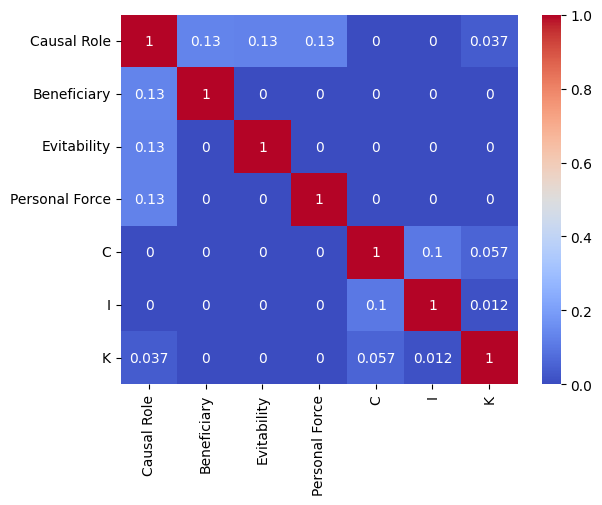

In [51]:
assoc_matrix = categorical_assoc_matrix(CIK_labels_df, ["Causal Role", "Beneficiary", "Evitability", "Personal Force", "C", "I", "K"])

print(assoc_matrix.to_string())

sns.heatmap(assoc_matrix.astype(float), annot=True, cmap="coolwarm")
plt.show()
